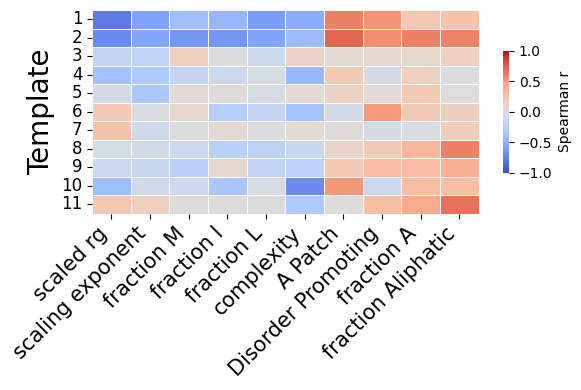


Plotted 10 features: ['scaled rg', 'scaling exponent', 'fraction M', 'fraction I', 'fraction L', 'complexity', 'A Patch', 'Disorder Promoting', 'fraction A', 'fraction Aliphatic']


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

def simplify_label(label):
    label = re.sub(r'^(nardini_?|cider_?|sparrow_?)', '', label, flags=re.IGNORECASE)
    label = re.sub(r'_raw$', '', label)
    label = label.replace('_', ' ')
    label = re.sub(r'\bFrac\b', 'fraction', label, flags=re.IGNORECASE)
    label = re.sub(r'\s+', ' ', label).strip()
    return label

heatmap_df = pd.read_csv('/../../Data/Figure_5/heatmap_r_mean_clustered.csv', index_col=0)

# Explicitly specify columns to plot
selected_features = [
    'sparrow_scaled_rg',
    'sparrow_scaling_exponent',
    'nardini_Frac M_raw',
    'nardini_Frac I_raw',
    'nardini_Frac L_raw',
    'sparrow_complexity',
    'nardini_A Patch_raw',
    'nardini_Disorder Promoting_raw',
    'nardini_Frac A_raw',
    'nardini_Frac Aliphatic_raw',
]

# Verify all columns exist
missing = [f for f in selected_features if f not in heatmap_df.columns]
if missing:
    print(f"Warning: missing columns: {missing}")
    selected_features = [f for f in selected_features if f in heatmap_df.columns]

heatmap_zoomed = heatmap_df[selected_features]
simplified_labels = [simplify_label(f) for f in selected_features]

fig, ax = plt.subplots(figsize=(max(6, len(selected_features) * 0.6), 4))

sns.heatmap(
    heatmap_zoomed,
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={'label': 'Spearman r', 'shrink': 0.6},
    annot=False,
    ax=ax
)

ax.set_xticklabels(simplified_labels, rotation=45, ha='right', fontsize=15)
ax.set_yticklabels([str(i) for i in range(1, len(heatmap_zoomed) + 1)], fontsize=12)
ax.set_ylabel('Template', fontsize=20)

plt.tight_layout()
#plt.savefig('heatmap_zoomed.svg', format='svg', bbox_inches='tight')
#plt.savefig('heatmap_zoomed.png', format='png', bbox_inches='tight', dpi=300)
plt.show()

print(f"\nPlotted {len(selected_features)} features: {simplified_labels}")